In [ ]:
# Week3 Assignment-1
# Submitted by Tiya Singh, 20701012025, IGDTUW

In [6]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#ML libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

# Used to split dataset into training and testing data
from sklearn.model_selection import train_test_split

# Used to evaluate classification models
from sklearn.metrics import accuracy_score, confusion_matrix

# Converts text columns into numerical values
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Part A: Understanding the Dataset

In [7]:
#Q1. Dataset Overview Load the dataset and answer the following:

df = pd.read_csv("agriculture_yield_dataset.csv")
#How many rows and columns are present?
print("Rows, Columns:", df.shape)
#What are the names of all columns?
print("\nColumns:\n", df.columns)
#Display the first 10 records.
print("\nFirst 10 rows:\n", df.head(10))

Rows, Columns: (1500, 8)

Columns:
 Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 rows:
    rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4

In [8]:
#Q2. Data Types and Missing Values

#Check the data type of each column.
print("\nData Types:\n", df.dtypes)
#Identify whether any missing values are present.
missing = df.isnull().sum()
print("\nMissing Values:\n", missing)
#If missing values exist, mention the affected columns.
missing = df.isnull().sum()
print("\nMissing Values:\n", missing)


Data Types:
 rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
 rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Missing Values:
 rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [9]:
#Q3. Descriptive Statistics Generate summary statistics for all numerical features and answer:

desc = df.describe()
print(desc)
#Which feature has the highest mean value?
mean_vals = df.select_dtypes(include=np.number).mean()
print("\nHighest mean feature:", mean_vals.idxmax())
#Which feature has the highest standard deviation?
std_vals = df.select_dtypes(include=np.number).std()
print("Highest std feature:", std_vals.idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [ ]:
#Part B: Exploratory Data Analysis (EDA)

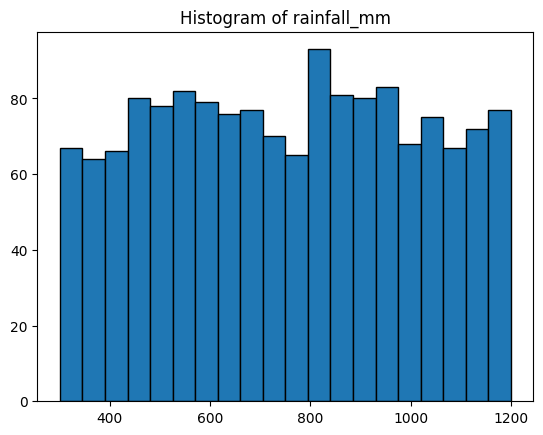

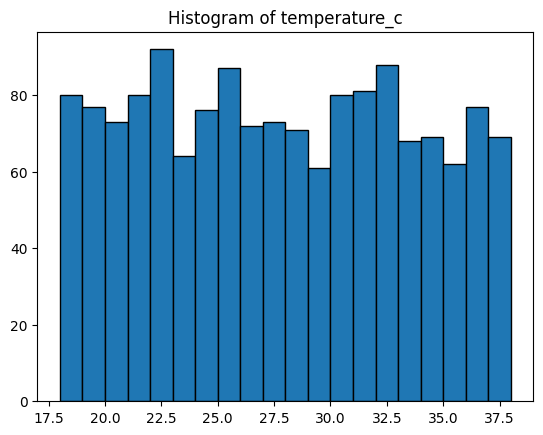

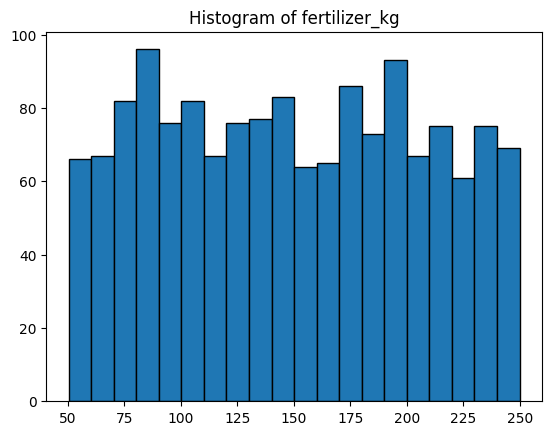

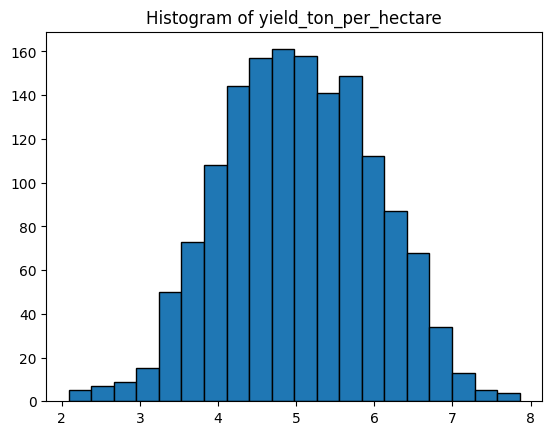

In [10]:
#Q4. Distribution Analysis Create histograms for:
# rainfall_mm   temperature_c   fertilizer_kg   yield_ton_per_hectare
#Write 2–3 observations from each histogram.

cols = ["rainfall_mm", "temperature_c", "fertilizer_kg", "yield_ton_per_hectare"]
for col in cols:
    plt.figure()
    plt.hist(df[col], bins=20, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


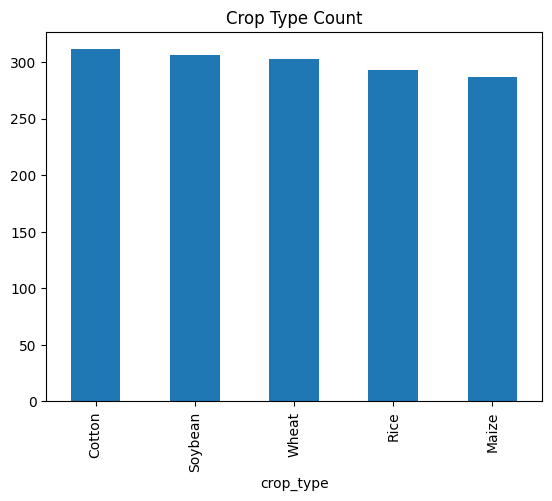

Most frequent crop: Cotton


In [11]:
#Q5. Crop Type Analysis  Find the number of records for each crop type.
# Create a count plot (bar chart) for crop_type.   Which crop appears most frequently?

print(df["crop_type"].value_counts())
df["crop_type"].value_counts().plot(kind="bar", title="Crop Type Count")
plt.show()
print("Most frequent crop:", df["crop_type"].value_counts().idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


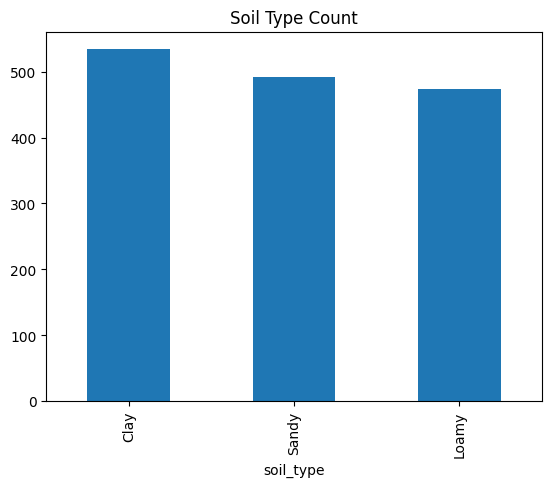

Most common soil type: Clay


In [12]:
#Q6. Soil Type Analysis
#Find the frequency of each soil type.   Create a count plot for soil_type.
# Which soil type is most common?

print(df["soil_type"].value_counts())
df["soil_type"].value_counts().plot(kind="bar", title="Soil Type Count")
plt.show()
print("Most common soil type:", df["soil_type"].value_counts().idxmax())

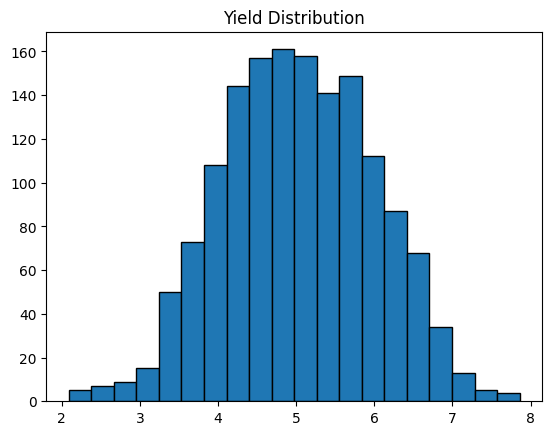

The yield distribution is approximately normal, as it shows a bell-shaped curve centered around the mean. There are no significant outliers, though a few slightly low and high values exist at the extremes.


In [24]:
#Q7. Yield Distribution Create a histogram of yield_ton_per_hectare.

plt.hist(df["yield_ton_per_hectare"], bins=20, edgecolor="black")
plt.title("Yield Distribution")
plt.show()

# Is the distribution approximately normal?   Are there any noticeable outliers
print("The yield distribution is approximately normal, as it shows a bell-shaped curve centered around the mean. There are no significant outliers, though a few slightly low and high values exist at the extremes.")

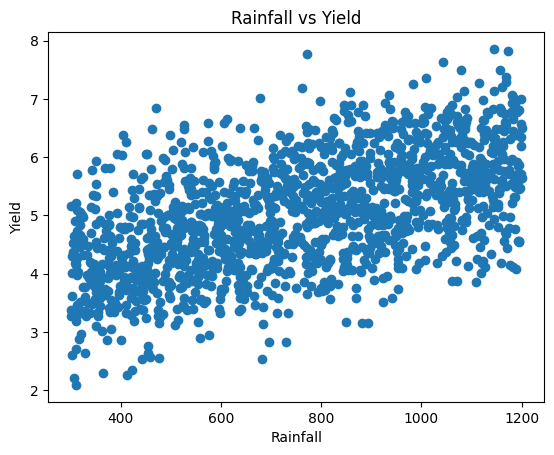

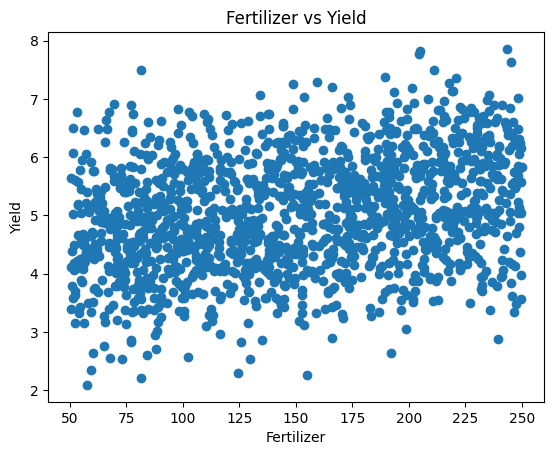

Rainfall has a stronger relationship with yield than fertilizer as rainfall shows a more visible positive correlation with yield, while fertilizer shows a weak and scattered relationship.


In [23]:
#Q8. Scatter Plot Analysis Create scatter plots of: 1. rainfall_mm vs yield_ton_per_hectare  2. fertilizer_kg vs yield_ton_per_hectare

plt.scatter(df["rainfall_mm"], df["yield_ton_per_hectare"])
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

plt.scatter(df["fertilizer_kg"], df["yield_ton_per_hectare"])
plt.title("Fertilizer vs Yield")
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

#Based on the plots:  Which feature appears to have a stronger relationship with yield?
print("Rainfall has a stronger relationship with yield than fertilizer as rainfall shows a more visible positive correlation with yield, while fertilizer shows a weak and scattered relationship.")

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

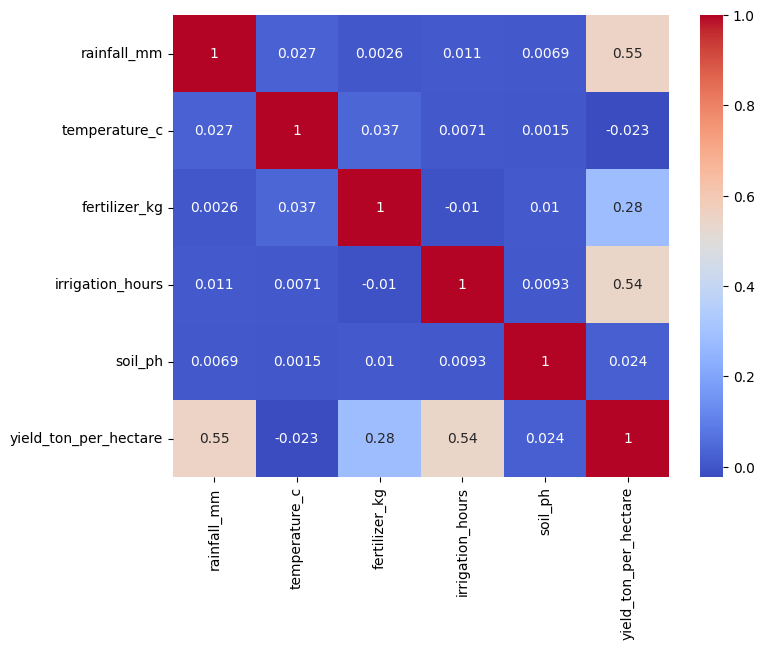

Top correlated with yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [15]:
#Q9. Correlation Analysis  Generate a correlation matrix for numerical features.
# Create a heatmap.   Identify the top three features most correlated with crop yield.

import seaborn as sns
corr = df.select_dtypes(include=np.number).corr()
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()
print("Top correlated with yield:")
print(corr["yield_ton_per_hectare"].sort_values(ascending=False)[1:4])

In [16]:
#Q10. Group-Based Analysis Calculate the average yield for:
# Each crop type   Each soil type  Which crop and soil type have the highest average yield?

print(df.groupby("crop_type")["yield_ton_per_hectare"].mean())
print("\nBest crop:")
print(df.groupby("crop_type")["yield_ton_per_hectare"].mean().idxmax())
print("\nSoil type yield:")
print(df.groupby("soil_type")["yield_ton_per_hectare"].mean())
print("\nBest soil:")
print(df.groupby("soil_type")["yield_ton_per_hectare"].mean().idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Best crop:
Rice

Soil type yield:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Best soil:
Loamy


In [ ]:
#Part C: Data Preparation

In [17]:
#Q11. Feature Encoding The dataset contains categorical variables.
# Identify the categorical columns.   Convert them into numerical form using One-Hot Encoding.
# Display the first five rows of the transformed dataset.

df_encoded = pd.get_dummies(df, columns=["crop_type", "soil_type"], drop_first=True)
print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat  soil_type_Loamy  soil_type_Sandy  
0            

In [22]:
#Q12. Feature Selection Separate:
# Input features (X)   Target variable (y)  Specify which column is being used as the target variable.

X = df_encoded.drop("yield_ton_per_hectare", axis=1)
y = df_encoded["yield_ton_per_hectare"]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target variable is yield_ton_per_hectare")

X shape: (1500, 11)
y shape: (1500,)
Target variable is yield_ton_per_hectare


In [ ]:
#Part D: Machine Learning

In [20]:
#Q13. Train-Test Split
#Split the dataset into:  80% Training Data   20% Testing Data
#Display the shape of:  X_train   X_test   y_train   y_test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


In [21]:
#Q14. Linear Regression Model
# Train a Linear Regression model.
# Display the model coefficients and intercept.   Which feature has the highest positive coefficient?

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions (optional)
y_pred = model.predict(X_test)

# Coefficients + intercept
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeff_df.sort_values(by="Coefficient", ascending=False))

print("\nHighest positive coefficient feature:")
print(coeff_df.loc[coeff_df["Coefficient"].idxmax(), "Feature"])

Intercept: 1.587132027736121
              Feature  Coefficient
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
5     crop_type_Maize     0.238931
3    irrigation_hours     0.198327
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
10    soil_type_Sandy    -0.490933

Highest positive coefficient feature:
crop_type_Rice
